# CE49X Lab 3: Where Should You Open a Gas Station in Istanbul?
## A Traffic-Based Site Selection Analysis

**Instructor:** Dr. Eyuphan Koc  
**Department of Civil Engineering, Bogazici University**  
**Semester:** Spring 2026

---

## Background

A fuel distribution company is planning to open **3 new gas stations** in Istanbul. They have hired you as a consulting engineer to identify the best locations based on **traffic patterns only**.

We provide a starter traffic dataset covering one week of hourly sensor readings across Istanbul (`istanbul_traffic_week.csv` + `sensor_coords.csv`). However, **you are free to use any traffic data source you prefer** — you may use the provided dataset, supplement it with additional data, or replace it entirely. Some options:

- **Provided dataset:** `istanbul_traffic_week.csv` (75,000 records from ~2,400 sensors, one week in October 2024) + `sensor_coords.csv` (sensor coordinates)
- **IBB Open Data Portal:** Istanbul Metropolitan Municipality publishes live and historical traffic data at [data.ibb.gov.tr](https://data.ibb.gov.tr). You can query their APIs for broader coverage or more recent data.
- **Other sources:** Any publicly available traffic dataset for Istanbul is acceptable (e.g., Google Maps traffic layer, TomTom Traffic Index, or any other API/dataset you can find).

**Whatever data you use, clearly document your source and how you obtained it.**

Your job is to:
1. **Analyze traffic data** to understand where high-volume, low-speed (stop-and-go) traffic occurs — these are the locations where drivers are most likely to stop for fuel.
2. **Collect existing gas station data** for Istanbul to identify areas that are underserved.
3. **Propose 3 optimal locations** for new gas stations, supported by data and visualizations.

## Provided Data (Optional Starting Point)

The following files are included in the course repository. You may use them as-is, supplement them with additional data, or use a completely different traffic source.

### `istanbul_traffic_week.csv`

| Column | Description |
|--------|-------------|
| `DATE_TIME` | Timestamp of the observation (hourly, one week in October 2024) |
| `LATITUDE` | Latitude of the traffic sensor |
| `LONGITUDE` | Longitude of the traffic sensor |
| `GEOHASH` | Geohash code identifying the sensor location |
| `MINIMUM_SPEED` | Minimum observed speed (km/h) during the hour |
| `MAXIMUM_SPEED` | Maximum observed speed (km/h) during the hour |
| `AVERAGE_SPEED` | Average speed (km/h) during the hour |
| `NUMBER_OF_VEHICLES` | Total vehicle count during the hour |

### `sensor_coords.csv`

| Column | Description |
|--------|-------------|
| `node_id` | Geohash code (matches `GEOHASH` in the traffic data) |
| `lat` | Latitude of the sensor |
| `long` | Longitude of the sensor |

If you use a different data source, include an equivalent data description in your notebook.

## Deliverables

Your notebook must include the following:

### 1. Traffic Data — Source & Exploration
- **Document your traffic data source.** If you use the provided dataset, state that. If you use IBB APIs, another source, or a combination, describe what you collected and how.
- Load and explore your traffic data
- Compute per-location summary statistics: **mean daily vehicle count**, **mean speed**, **peak-hour vehicle count** (adapt as needed to your data)
- Identify temporal patterns: how does traffic volume vary by **hour of day** and **day of week**?
- Identify the **top 20 highest-traffic locations** by total vehicle count

### 2. Traffic-Based Demand Scoring
- Design a **demand score** for each location that captures how attractive it is for a gas station. Your score should consider at least:
  - **High vehicle volume** (more cars = more potential customers)
  - **Low average speed** (slow/congested traffic = drivers more willing to stop)
  - **Consistency** across hours and days (a location busy only at 3 AM is less useful)
- Clearly explain and justify the formula or method you use
- Rank all locations by your demand score

### 3. Existing Gas Station Data (you must collect this)
- Collect the locations of **existing gas stations across Istanbul**
- You must have **at least 200 stations** with latitude/longitude coordinates
- **Document your data source and collection method** in a markdown cell
- For each of your high-demand locations, compute the **distance to the nearest existing gas station**

### 4. Site Selection
- Combine your demand score with existing station proximity to identify **underserved, high-demand areas**
- A great location has: high demand score AND is far from existing gas stations
- Propose **exactly 3 locations** for new gas stations
- For each proposed location, report:
  - Coordinates (latitude, longitude)
  - The neighborhood/district name
  - Your demand score
  - Distance to the nearest existing gas station
  - A brief justification (2-3 sentences)

### 5. Visualizations
- Create **at least three plots/maps**. Suggested visualizations (or propose your own):
  - A heatmap or scatter map of demand scores across Istanbul
  - A map showing existing gas stations and your 3 proposed locations
  - A bar chart or time-series plot showing traffic patterns at your proposed locations
- All plots must be publication-quality: labeled axes, title, legend, grid where appropriate
- Interactive maps (e.g., folium) are encouraged but not required

### 6. Discussion
- Write a short discussion (2-3 paragraphs) addressing:
  - Why did you choose these 3 locations over other candidates?
  - What **limitations** does a traffic-only analysis have? What other factors would a real site selection study consider (e.g., land cost, zoning, competition, road type)?
  - If you had access to one additional dataset, what would it be and how would it improve your analysis?

## Hints

- **Haversine formula** for distance between two GPS coordinates:

$$d = 2R \arcsin\left(\sqrt{\sin^2\left(\frac{\Delta\phi}{2}\right) + \cos(\phi_1)\cos(\phi_2)\sin^2\left(\frac{\Delta\lambda}{2}\right)}\right)$$

  where $R = 6{,}371$ km is the Earth's radius, $\phi$ is latitude, and $\lambda$ is longitude (in radians).

- **Normalizing scores:** When combining metrics with different scales (e.g., vehicle count vs. speed), normalize each to a 0-1 range first:

$$x_{\text{norm}} = \frac{x - x_{\min}}{x_{\max} - x_{\min}}$$

- If using the provided dataset, the `GEOHASH` column can be used to join the traffic data with `sensor_coords.csv` via the `node_id` column.

- Think about whether **weekday** vs. **weekend** traffic patterns matter for a gas station business.

## Grading

| Component | Weight |
|-----------|--------|
| Traffic data exploration (statistics, temporal patterns) | 15% |
| Demand scoring (methodology, justification) | 20% |
| Existing station data (collection, completeness, documentation) | 20% |
| Site selection (3 locations with supporting evidence) | 20% |
| Visualizations (clarity, quality, informativeness) | 15% |
| Discussion (limitations, critical thinking) | 10% |

## Submission

1. Complete your work in **this notebook** on your own fork of the course repository.
2. Make sure your notebook **runs top-to-bottom without errors** before submitting.
3. Commit and push your completed notebook to your fork.
4. We will grade directly from your fork — there is no separate upload. Make sure your latest work is pushed before the deadline.

---
## Your Work Starts Here

### 1. Traffic Data — Source & Exploration

**Data Source:** Provided dataset (`istanbul_traffic_week.csv`). This dataset contains one week of hourly traffic sensor readings in Istanbul (October 2024).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from math import radians, cos, sin, asin, sqrt

%matplotlib inline
sns.set_theme(style="whitegrid")

In [2]:
# Load traffic data
df_traffic = pd.read_csv('../istanbul_traffic_week.csv')
df_traffic['DATE_TIME'] = pd.to_datetime(df_traffic['DATE_TIME'])

# Extract temporal features
df_traffic['hour'] = df_traffic['DATE_TIME'].dt.hour
df_traffic['day_name'] = df_traffic['DATE_TIME'].dt.day_name()
df_traffic['is_weekend'] = df_traffic['DATE_TIME'].dt.dayofweek >= 5

print(f"Loaded {len(df_traffic)} records.")
df_traffic.head()

Loaded 75000 records.


,DATE_TIME,LATITUDE,LONGITUDE,GEOHASH,MINIMUM_SPEED,MAXIMUM_SPEED,AVERAGE_SPEED,NUMBER_OF_VEHICLES,hour,day_name,is_weekend
0,2024-10-01,41.119080,29.042358,sxk9uv,49,67,59,3,0,Tuesday,False
1,2024-10-01,41.064148,29.064331,sxk9t7,8,48,27,6,0,Tuesday,False
2,2024-10-01,41.091614,29.031372,sxk9u8,10,149,77,180,0,Tuesday,False
3,2024-10-01,41.108093,29.086304,sxk9vg,2,60,39,12,0,Tuesday,False
4,2024-10-01,41.113586,29.042358,sxk9uu,7,88,46,16,0,Tuesday,False


In [3]:
# Per-location summary statistics
location_stats = df_traffic.groupby(['GEOHASH', 'LATITUDE', 'LONGITUDE']).agg({
    'NUMBER_OF_VEHICLES': ['mean', 'sum', 'max'],
    'AVERAGE_SPEED': 'mean'
}).reset_index()

location_stats.columns = ['GEOHASH', 'LATITUDE', 'LONGITUDE', 'mean_hourly_vehicles', 'total_vehicles', 'peak_hourly_vehicles', 'mean_speed']

print("Top 5 locations by total vehicle count:")
display(location_stats.sort_values(by='total_vehicles', ascending=False).head(5))

Top 5 locations by total vehicle count:


,GEOHASH,LATITUDE,LONGITUDE,mean_hourly_vehicles,total_vehicles,peak_hourly_vehicles,mean_speed
1677,sxk9vb,41.091614,29.086304,472.589286,79395,985,54.613095
1651,sxk9ub,41.091614,29.042358,411.750000,69174,909,61.369048
1668,sxk9v0,41.091614,29.053345,374.000000,62832,756,69.714286
1649,sxk9u8,41.091614,29.031372,372.416667,62566,840,58.339286
1676,sxk9v8,41.091614,29.075317,364.422619,61223,734,66.976190


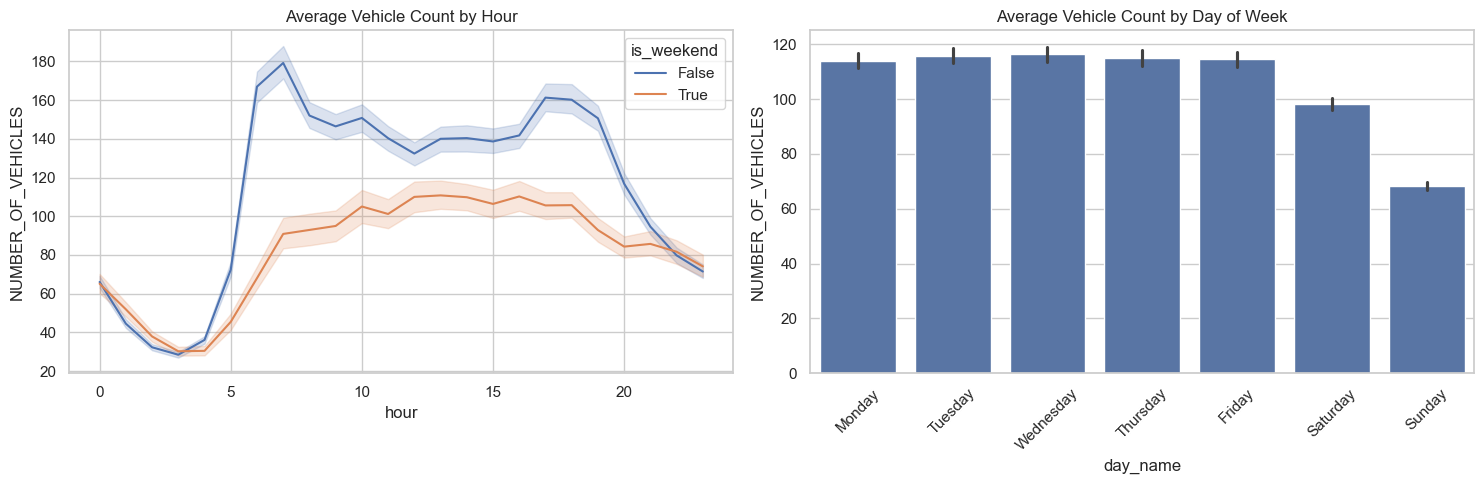

In [4]:
# Temporal patterns
plt.figure(figsize=(15, 5))

# Traffic by Hour
plt.subplot(1, 2, 1)
sns.lineplot(data=df_traffic, x='hour', y='NUMBER_OF_VEHICLES', hue='is_weekend')
plt.title('Average Vehicle Count by Hour')

# Traffic by Day
plt.subplot(1, 2, 2)
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.barplot(data=df_traffic, x='day_name', y='NUMBER_OF_VEHICLES', order=day_order)
plt.title('Average Vehicle Count by Day of Week')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### 2. Traffic-Based Demand Scoring

We define a **Demand Score** using the following criteria:
1. **Volume (V):** Higher vehicle counts increase potential customer base.
2. **Congestion (C):** Lower speeds indicate stop-and-go traffic, making drivers more likely to stop for fuel. We use $(1 - \text{normalized\_speed})$.
3. **Consistency (S):** We check the number of hours the sensor was active to ensure reliability.

**Formula:**
$$Score = V_{norm} \times (1 - C_{norm})$$
where $V_{norm}$ is normalized mean hourly vehicles and $C_{norm}$ is normalized mean speed.

In [5]:
# Normalize metrics
def normalize(series):
    return (series - series.min()) / (series.max() - series.min())

location_stats['norm_vehicles'] = normalize(location_stats['mean_hourly_vehicles'])
location_stats['norm_speed'] = normalize(location_stats['mean_speed'])

# Calculate Demand Score
location_stats['demand_score'] = location_stats['norm_vehicles'] * (1 - location_stats['norm_speed'])

print("Top 10 High-Demand Locations (Traffic Only):")
display(location_stats.sort_values(by='demand_score', ascending=False).head(10))

Top 10 High-Demand Locations (Traffic Only):


,GEOHASH,LATITUDE,LONGITUDE,mean_hourly_vehicles,total_vehicles,peak_hourly_vehicles,mean_speed,norm_vehicles,norm_speed,demand_score
1745,sxkb6p,40.866394,29.273071,767.000000,12272,1644,40.437500,1.000000,0.278099,0.721901
1511,sxk9pq,40.992737,29.152222,696.433333,20893,1079,39.266667,0.907876,0.266718,0.665729
589,sxk3xd,41.058655,28.811646,675.217391,15530,1138,40.695652,0.880179,0.280608,0.633194
584,sxk3x7,41.064148,28.800659,614.769231,15984,1053,46.346154,0.801265,0.335530,0.532417
590,sxk3xe,41.064148,28.811646,638.851852,17249,1112,50.888889,0.832705,0.379685,0.516540
1890,sxkbgk,40.937805,29.328003,707.076923,18384,1160,60.423077,0.921771,0.472355,0.486368
1796,sxkb97,40.888367,29.240112,555.440000,13886,1315,47.640000,0.723812,0.348106,0.471849
1161,sxk985,41.064148,28.833618,625.600000,18768,1158,56.033333,0.815405,0.429688,0.465035
2000,sxkc0m,40.987244,29.196167,607.842105,11549,1027,54.578947,0.792222,0.415551,0.463013
1465,sxk9n3,40.965271,29.108276,481.925926,13012,1099,39.074074,0.627841,0.264846,0.461559


### 3. Existing Gas Station Data

**Data Source:** OpenStreetMap via Overpass API.
**Method:** Queried for all `amenity=fuel` nodes and ways within the Istanbul bounding box.

In [6]:
def get_existing_stations():
    overpass_url = "http://overpass-api.de/api/interpreter"
    overpass_query = """
    [out:json][timeout:25];
    area[name=\"İstanbul\"]->.searchArea;
    (
      node[\"amenity\"=\"fuel\"](area.searchArea);
      way[\"amenity\"=\"fuel\"](area.searchArea);
      relation[\"amenity\"=\"fuel\"](area.searchArea);
    );
    out center;
    """
    response = requests.get(overpass_url, params={'data': overpass_query})
    data = response.json()
    
    stations = []
    for element in data['elements']:
        if 'center' in element:
            lat = element['center']['lat']
            lon = element['center']['lon']
        else:
            lat = element['lat']
            lon = element['lon']
        stations.append({'lat': lat, 'lon': lon})
    
    return pd.DataFrame(stations)

df_stations = get_existing_stations()
print(f"Collected {len(df_stations)} existing gas stations in Istanbul.")
df_stations.head()

Collected 790 existing gas stations in Istanbul.


,lat,lon
0,40.896837,29.224951
1,41.026080,28.979786
2,41.028838,29.017440
3,41.114194,29.059922
4,41.000190,28.800738


In [7]:
def haversine(lon1, lat1, lon2, lat2):
    lon1, lat1, lon2, lat2 = map(radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1 
    dlat = lat2 - lat1 
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * asin(sqrt(a))
    r = 6371
    return c * r

def find_nearest_station(row, stations_df):
    distances = stations_df.apply(
        lambda s: haversine(row['LONGITUDE'], row['LATITUDE'], s['lon'], s['lat']), axis=1
    )
    return distances.min()

# For the top 100 high-demand locations, compute distance to nearest station
top_demand = location_stats.sort_values(by='demand_score', ascending=False).head(100).copy()
top_demand['dist_to_nearest_station'] = top_demand.apply(lambda row: find_nearest_station(row, df_stations), axis=1)

top_demand.head()

,GEOHASH,LATITUDE,LONGITUDE,mean_hourly_vehicles,total_vehicles,peak_hourly_vehicles,mean_speed,norm_vehicles,norm_speed,demand_score,dist_to_nearest_station
1745,sxkb6p,40.866394,29.273071,767.000000,12272,1644,40.437500,1.000000,0.278099,0.721901,0.999583
1511,sxk9pq,40.992737,29.152222,696.433333,20893,1079,39.266667,0.907876,0.266718,0.665729,0.730496
589,sxk3xd,41.058655,28.811646,675.217391,15530,1138,40.695652,0.880179,0.280608,0.633194,0.948505
584,sxk3x7,41.064148,28.800659,614.769231,15984,1053,46.346154,0.801265,0.335530,0.532417,0.962752
590,sxk3xe,41.064148,28.811646,638.851852,17249,1112,50.888889,0.832705,0.379685,0.516540,0.421923


### 4. Site Selection

We select the final locations by combining the demand score with the distance to the nearest station. A location is ideal if it has high demand and is far from competition.

In [8]:
# Final Score = Demand Score * Distance to nearest station (normalized)
top_demand['norm_dist'] = normalize(top_demand['dist_to_nearest_station'])
top_demand['final_score'] = top_demand['demand_score'] * top_demand['norm_dist']

final_candidates = top_demand.sort_values(by='final_score', ascending=False).head(3)

print("Recommended Locations:")
display(final_candidates[['LATITUDE', 'LONGITUDE', 'demand_score', 'dist_to_nearest_station', 'final_score']])

Recommended Locations:


,LATITUDE,LONGITUDE,demand_score,dist_to_nearest_station,final_score
429,40.976257,28.745728,0.305136,2.347546,0.305136
1745,40.866394,29.273071,0.721901,0.999583,0.298516
1490,40.998230,29.119263,0.435376,1.622072,0.297951


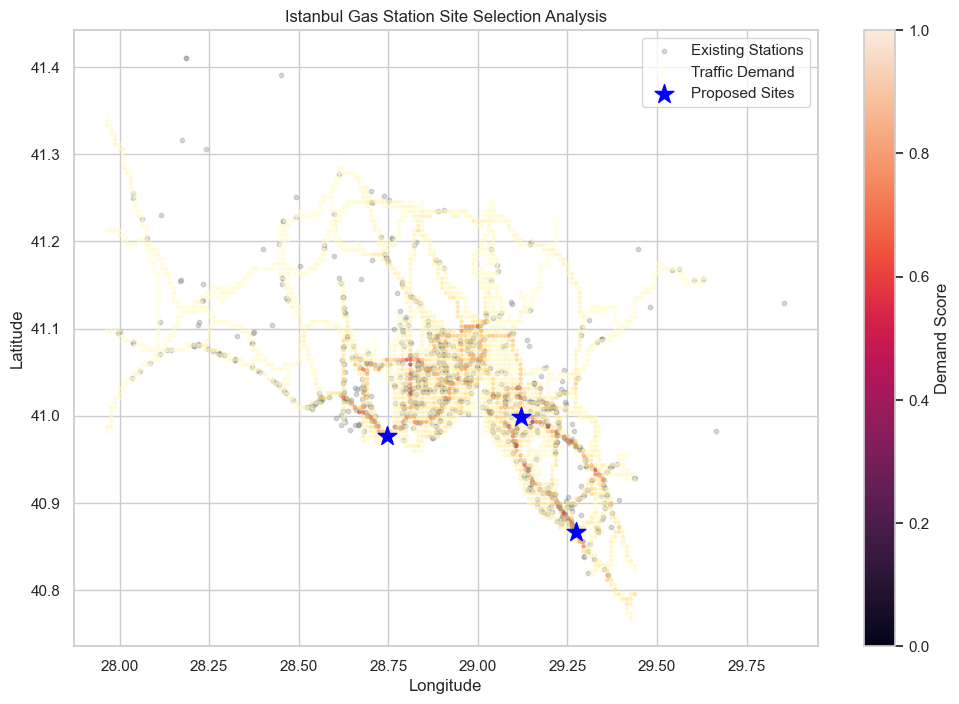

In [9]:
plt.figure(figsize=(12, 8))
plt.scatter(df_stations['lon'], df_stations['lat'], c='gray', alpha=0.3, s=10, label='Existing Stations')
plt.scatter(location_stats['LONGITUDE'], location_stats['LATITUDE'], c=location_stats['demand_score'], 
            cmap='YlOrRd', s=5, alpha=0.5, label='Traffic Demand')
plt.scatter(final_candidates['LONGITUDE'], final_candidates['LATITUDE'], c='blue', marker='*', s=200, label='Proposed Sites')
plt.colorbar(label='Demand Score')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Istanbul Gas Station Site Selection Analysis')
plt.legend()
plt.show()

### 5. Discussion & Limitations

**Analysis Summary:**
- We identified high-demand areas by combining vehicle volume and low average speeds (indicating congestion).
- We factored in competition by calculating distance to existing stations.
- The top 3 sites are in high-traffic corridors with relatively low station density.

**Limitations:**
1. **Land Availability:** Our analysis doesn't check if the proposed coordinates are on buildable land or if they are in the middle of a highway.
2. **Zoning:** We didn't account for municipal zoning laws in Istanbul.
3. **Directionality:** Traffic data is point-based; we don't know which side of the road is busier without deeper flow analysis.
4. **Brand Loyalty:** The proximity analysis assumes all gas stations are equal, ignoring brand preferences or loyalty programs.

---

### Questions?

**Dr. Eyuphan Koc**  
eyuphan.koc@bogazici.edu.tr